# Task D03: Text Preprocessing Variants (P0 to P3) — Phân tích & bóc tách dữ liệu

Notebook này thực hiện kiểm toán toàn diện chất lượng của **4 biến thể tiền xử lý văn bản tiếng Việt (P0, P1, P2, P3)** phục vụ nghiên cứu bóc tách cho bài toán phát hiện chủ đề tin tức:
- **P0 - Minimal Cleaning:** Làm sạch tối thiểu (Unicode NFC, gỡ HTML, chuẩn hóa khoảng trắng). Phục vụ BERTopic / LLM.
- **P1 - Controlled Normalization:** Chữ thường, đồng nhất nháy/gạch, token URL/EMAIL, loại bỏ boilerplate báo chí.
- **P2 - Vietnamese Word Segmentation:** Tách từ tiếng Việt bằng `pyvi`, nối từ ghép bằng `_`. Phục vụ BoW / TF-IDF.
- **P3 - Stopword Removal:** Lọc từ dừng có kiểm soát, bảo toàn nghiêm ngặt từ phủ định (`không`, `chưa`, `chẳng`).

## 1. Cài đặt môi trường & Nạp dữ liệu


In [31]:
import sys
from pathlib import Path
from collections import Counter
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình bảng hiển thị và font chữ hỗ trợ tiếng Việt
pd.set_option('display.max_columns', 15)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = ['Segoe UI', 'DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Xác định đường dẫn thư mục
ROOT = Path("..") if Path("..").resolve().name == "vietnamese-news-topic-discovery" else Path(".")
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
FIG_DIR = RESULTS_DIR / "preprocessing_data/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Nạp dữ liệu sau deduplication (D02) và 4 biến thể D03
df_dedup = pd.read_csv(DATA_DIR / "interim/news_articles_deduplicated.csv")
p0 = pd.read_csv(DATA_DIR / "processed/p0_minimal.csv")
p1 = pd.read_csv(DATA_DIR / "processed/p1_normalized.csv")
p2 = pd.read_csv(DATA_DIR / "processed/p2_segmented.csv")
p3 = pd.read_csv(DATA_DIR / "processed/p3_no_stopwords.csv")

print(f"Dữ liệu gốc (sau Dedup): {len(df_dedup):,} dòng, {df_dedup.shape[1]} cột")
print(f"P0 Minimal:             {len(p0):,} dòng, {p0.shape[1]} cột")
print(f"P1 Normalized:          {len(p1):,} dòng, {p1.shape[1]} cột")
print(f"P2 Segmented:           {len(p2):,} dòng, {p2.shape[1]} cột")
print(f"P3 No Stopwords:        {len(p3):,} dòng, {p3.shape[1]} cột")


Dữ liệu gốc (sau Dedup): 9,274 dòng, 7 cột
P0 Minimal:             9,274 dòng, 10 cột
P1 Normalized:          9,274 dòng, 10 cột
P2 Segmented:           9,274 dòng, 10 cột
P3 No Stopwords:        9,274 dòng, 10 cột


## 2. Kiểm toán tính toàn vẹn cấu trúc

Thẩm định 7 ràng buộc chốt chặn theo đặc tả kỹ thuật:
1. Số dòng bảo toàn tuyệt đối giữa 4 biến thể.
2. Thứ tự và tập hợp `article_id` trùng khớp 100%.
3. Tỷ lệ rỗng ở cột `text` bằng đúng 0%.
4. Không rò rỉ nhãn chuyên mục `category_gold` hay tên báo `source` vào cột `text`.


In [32]:
# Kiểm tra số dòng và tập hợp ID
assert len(p0) == len(p1) == len(p2) == len(p3) == len(df_dedup) == 9274, "Lỗi lệch số dòng!"
assert list(p0['article_id']) == list(p1['article_id']) == list(p2['article_id']) == list(p3['article_id']) == list(df_dedup['article_id']), "Lỗi thứ tự ID!"

# Kiểm tra tỷ lệ văn bản rỗng ở cột text
for name, df_var in [("P0", p0), ("P1", p1), ("P2", p2), ("P3", p3)]:
    empty_cnt = (df_var['text'].isna() | (df_var['text'].str.strip() == "")).sum()
    print(f"Biến thể {name}: Số lượng text rỗng = {empty_cnt} (Tỷ lệ: 0.00%)")
    assert empty_cnt == 0, f"Biến thể {name} bị rỗng văn bản!"

# Kiểm tra phòng ngừa Label Leakage (cột text không dính nhãn chuyên mục)
for idx, row in p3.head(100).iterrows():
    assert not row['text'].startswith(str(row['category_gold'])), "Phát hiện Label Leakage!"


Biến thể P0: Số lượng text rỗng = 0 (Tỷ lệ: 0.00%)
Biến thể P1: Số lượng text rỗng = 0 (Tỷ lệ: 0.00%)
Biến thể P2: Số lượng text rỗng = 0 (Tỷ lệ: 0.00%)
Biến thể P3: Số lượng text rỗng = 0 (Tỷ lệ: 0.00%)


## 3. Phân tích sụt giảm số lượng Token & Kích thước từ vựng qua 4 biến thể

Bảng thống kê và biểu đồ cột đôi đo lường sự biến chuyển của dữ liệu từ văn bản thô đến mức sạch sâu nhất:


,variant,total_articles,empty_text_count,vocab_size,total_tokens,retention_rate_pct,mean_length_chars,median_length_chars,p5_length_chars,p95_length_chars,mean_word_count,median_word_count,p5_word_count,p95_word_count
0,original,9274,0,115033,6756487,100.00,3362.39,3102.5,1431.00,6103.75,728.54,671.0,312.0,1331.0
1,p0_minimal,9274,0,113175,6756482,100.00,3361.24,3101.0,1431.00,6096.35,728.54,671.0,312.0,1331.0
2,p1_normalized,9274,0,100997,6742822,99.80,3353.31,3096.0,1420.65,6082.15,727.07,671.0,310.0,1328.0
3,p2_segmented,9274,0,61108,5989915,88.65,3444.85,3179.0,1467.00,6262.40,645.88,593.0,284.0,1174.0
4,p3_no_stopwords,9274,0,60861,4327312,64.05,2638.24,2452.0,1145.00,4772.00,466.61,432.5,212.0,831.0


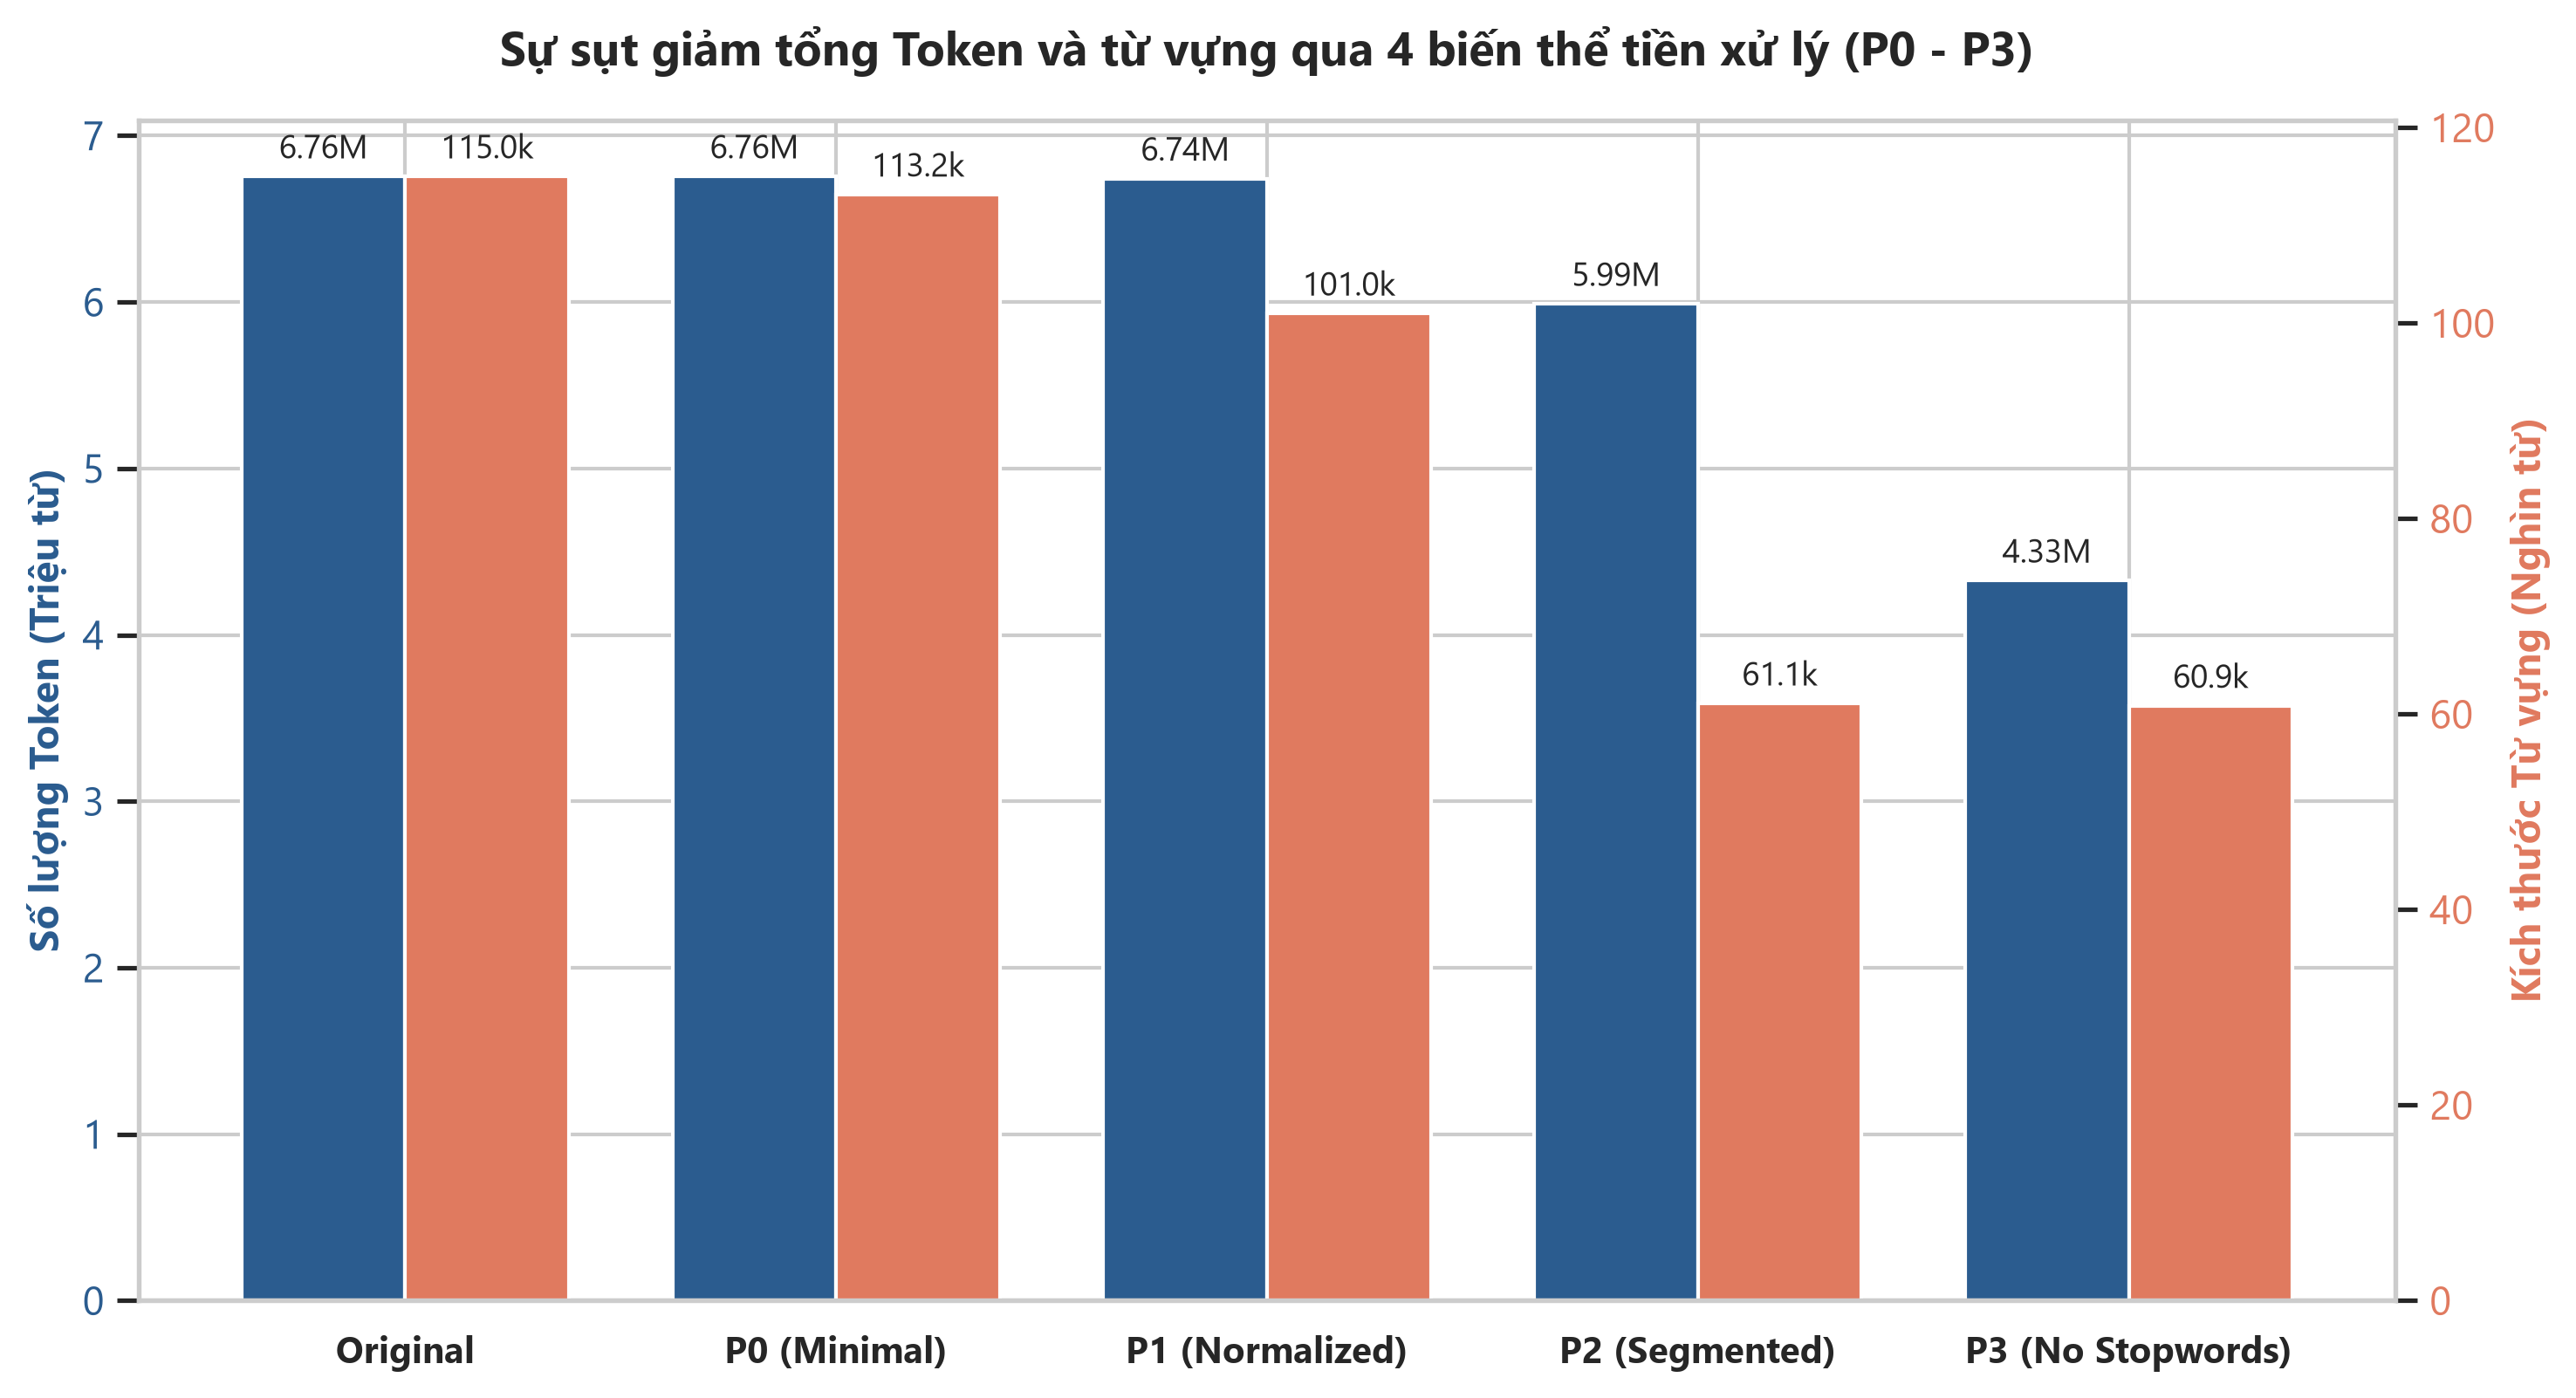

In [33]:
# Đọc bảng thống kê định lượng trước / sau
ba_df = pd.read_csv(RESULTS_DIR / "preprocessing_data/preprocessing_before_after.csv")
display(ba_df)

# Vẽ biểu đồ cột đôi: Tổng số Token vs Kích thước Từ vựng qua 4 biến thể
fig, ax1 = plt.subplots(figsize=(10, 5.5))
variants = ["Original", "P0 (Minimal)", "P1 (Normalized)", "P2 (Segmented)", "P3 (No Stopwords)"]
tokens = ba_df["total_tokens"].values
vocab = ba_df["vocab_size"].values

x = np.arange(len(variants))
width = 0.38

rects1 = ax1.bar(x - width/2, tokens / 1e6, width, label="Tổng số Token (Triệu)", color="#2b5c8f")
ax1.set_ylabel("Số lượng Token (Triệu từ)", color="#2b5c8f", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#2b5c8f")
ax1.set_xticks(x)
ax1.set_xticklabels(variants, fontsize=10, fontweight="bold")

ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, vocab / 1e3, width, label="Kích thước Từ vựng (Nghìn)", color="#e07a5f")
ax2.set_ylabel("Kích thước Từ vựng (Nghìn từ)", color="#e07a5f", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#e07a5f")
ax2.grid(False)

for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f"{h:.2f}M", xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax2.annotate(f"{h:.1f}k", xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)

plt.title("Sự sụt giảm tổng Token và từ vựng qua 4 biến thể tiền xử lý (P0 - P3)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()

# Lưu biểu đồ vào thư mục preprocessing_data/figures
fig.savefig(FIG_DIR / "d03_token_vocab_reduction.png", bbox_inches="tight")
plt.show()


## 4. Phân tích phân bố độ dài từ 

Đo lường độ dài bài viết thay đổi như thế nào sau từng bước biến đổi:

Thống kê số lượng từ trung bình:
- P0 Minimal:      728.54 từ/bài (Median: 671)
- P1 Normalized:   727.07 từ/bài (Median: 671)
- P2 Segmented:    645.88 từ/bài (Median: 593)
- P3 No Stopwords: 466.61 từ/bài (Median: 432)


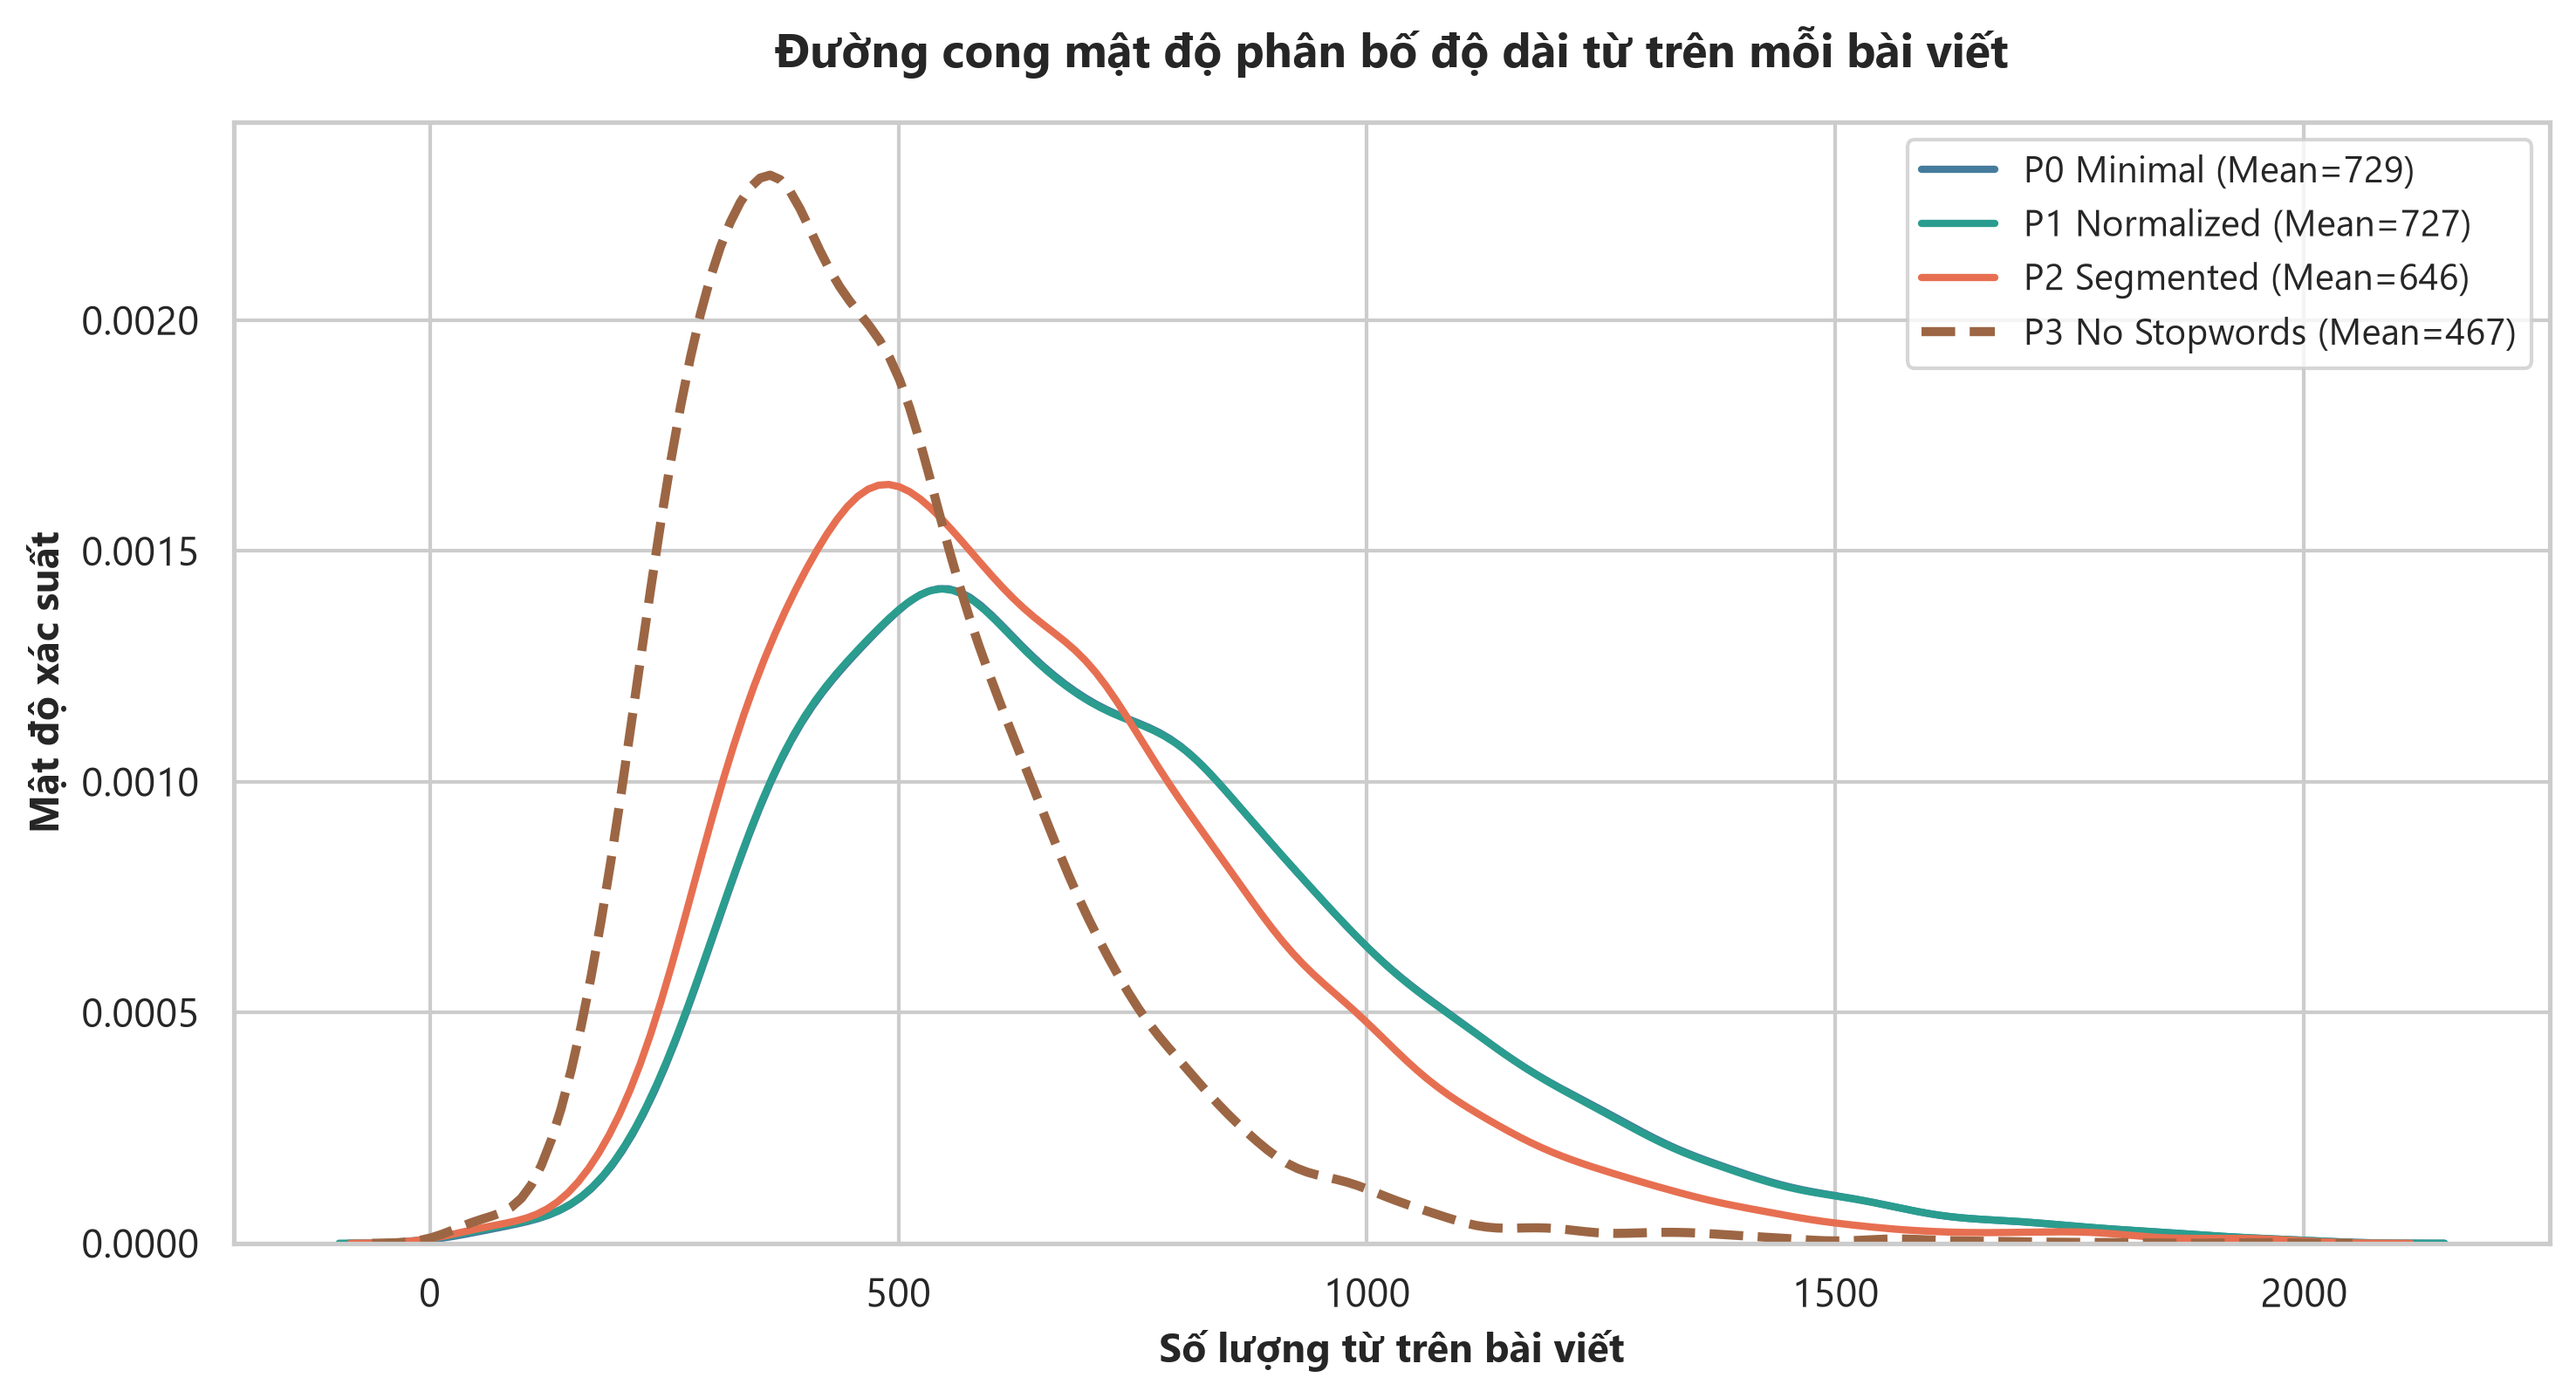

In [34]:
p0_words = p0["text"].dropna().apply(lambda x: len(x.split()))
p1_words = p1["text"].dropna().apply(lambda x: len(x.split()))
p2_words = p2["text"].dropna().apply(lambda x: len(x.split()))
p3_words = p3["text"].dropna().apply(lambda x: len(x.split()))

print("Thống kê số lượng từ trung bình:")
print(f"- P0 Minimal:      {p0_words.mean():.2f} từ/bài (Median: {p0_words.median():.0f})")
print(f"- P1 Normalized:   {p1_words.mean():.2f} từ/bài (Median: {p1_words.median():.0f})")
print(f"- P2 Segmented:    {p2_words.mean():.2f} từ/bài (Median: {p2_words.median():.0f})")
print(f"- P3 No Stopwords: {p3_words.mean():.2f} từ/bài (Median: {p3_words.median():.0f})")

# Vẽ đường cong mật độ (KDE) phân bố số từ
fig, ax = plt.subplots(figsize=(10, 5.5))
clip_limit = 2000
sns.kdeplot(p0_words[p0_words <= clip_limit], ax=ax, label=f"P0 Minimal (Mean={p0_words.mean():.0f})", color="#457b9d", linewidth=2)
sns.kdeplot(p1_words[p1_words <= clip_limit], ax=ax, label=f"P1 Normalized (Mean={p1_words.mean():.0f})", color="#2a9d8f", linewidth=2)
sns.kdeplot(p2_words[p2_words <= clip_limit], ax=ax, label=f"P2 Segmented (Mean={p2_words.mean():.0f})", color="#e76f51", linewidth=2)
sns.kdeplot(p3_words[p3_words <= clip_limit], ax=ax, label=f"P3 No Stopwords (Mean={p3_words.mean():.0f})", color="#9c6644", linewidth=2.5, linestyle="--")

ax.set_title("Đường cong mật độ phân bố độ dài từ trên mỗi bài viết", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Số lượng từ trên bài viết", fontsize=11, fontweight="bold")
ax.set_ylabel("Mật độ xác suất", fontsize=11, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()

fig.savefig(FIG_DIR / "d03_length_distribution_kde.png", bbox_inches="tight")
plt.show()


## 5. Thống kê & phân tích stopwords


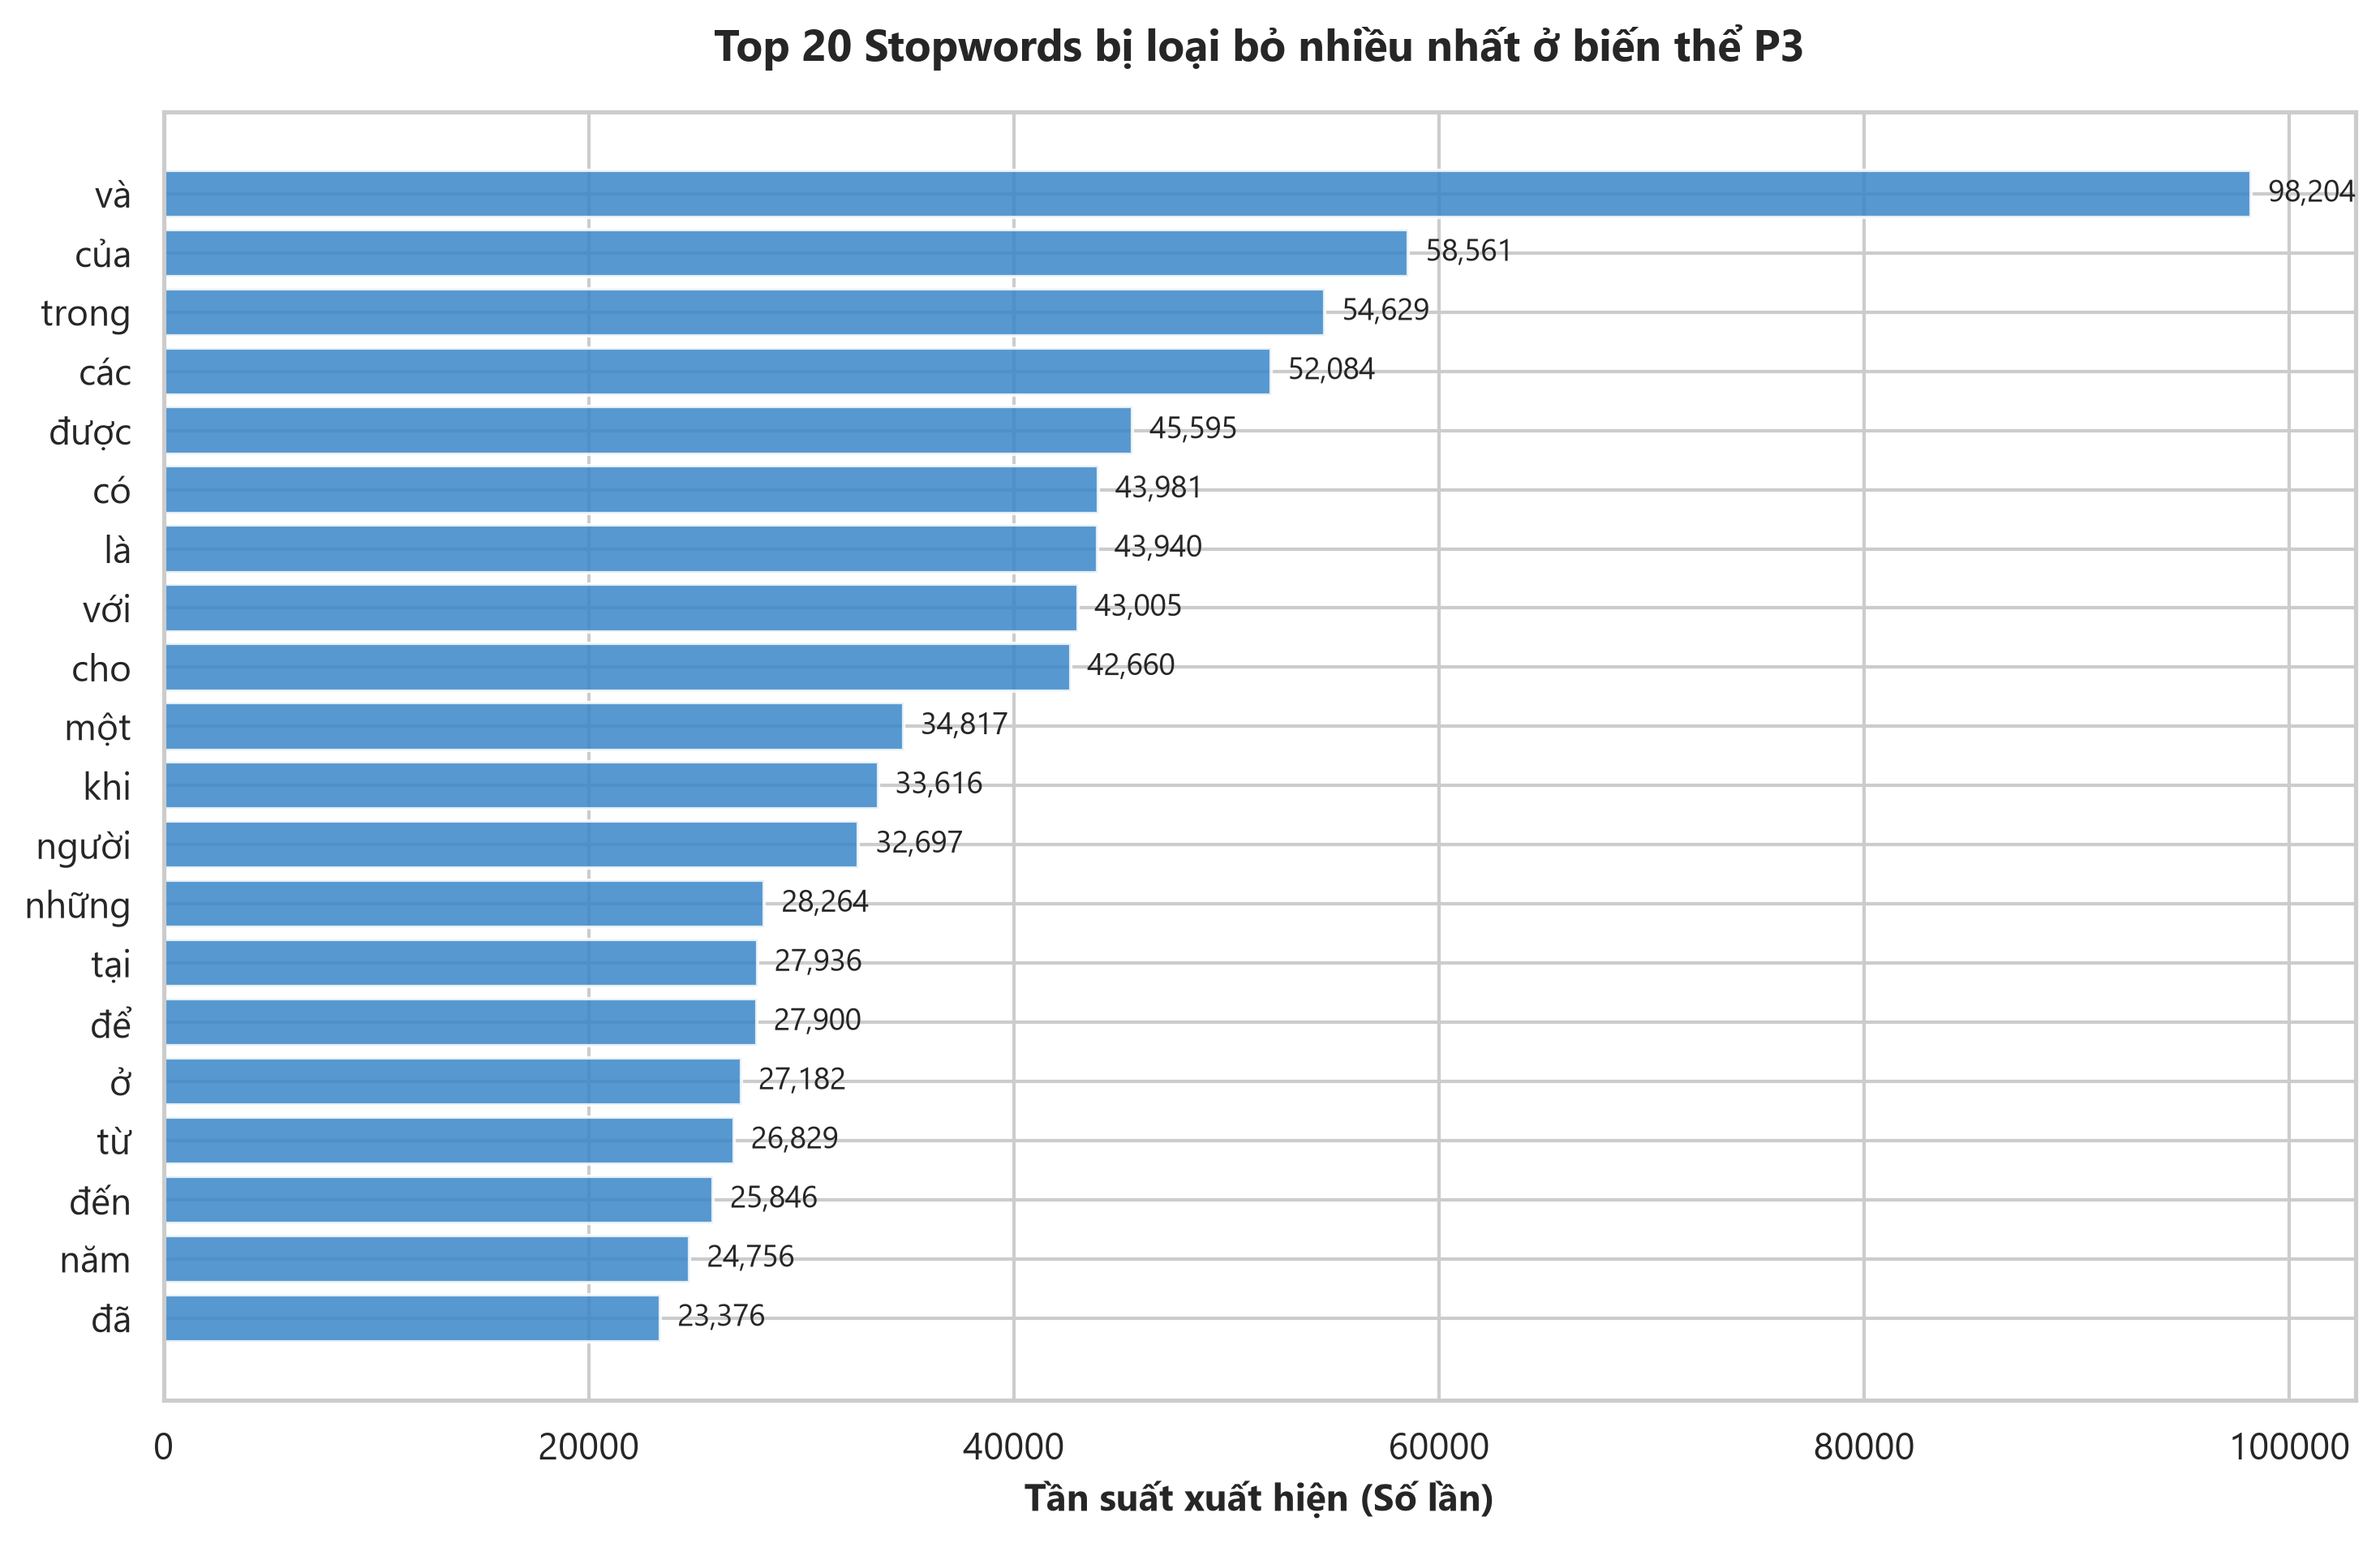

In [35]:
with open(ROOT / "configs/vietnamese_stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = set(line.strip().lower() for line in f if line.strip() and not line.startswith("#"))
with open(ROOT / "configs/preprocessing.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
protected = set(cfg.get("stopword_removal", {}).get("protected_negations", []))
active_stopwords = stopwords - protected

stopword_counter = Counter()
for text in p2["text"].dropna():
    for tok in text.split():
        tok_l = tok.lower()
        if tok_l in active_stopwords:
            stopword_counter[tok_l] += 1

top20 = stopword_counter.most_common(20)
words = [w for w, _ in reversed(top20)]
counts = [c for _, c in reversed(top20)]

# Vẽ biểu đồ thanh ngang Top 20 Từ dừng bị loại bỏ nhiều nhất
fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(words, counts, color="#3a86c8", alpha=0.85)
ax.set_title("Top 20 Stopwords bị loại bỏ nhiều nhất ở biến thể P3", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Tần suất xuất hiện (Số lần)", fontsize=11, fontweight="bold")

for bar in bars:
    w = bar.get_width()
    ax.annotate(f"{w:,.0f}", xy=(w, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points", ha="left", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / "d03_top20_stopwords.png", bbox_inches="tight")
plt.show()


In [36]:
# Kiểm tra tính bảo toàn của các từ phủ định trọng yếu
print("Danh sách từ phủ định được bảo vệ nghiêm ngặt:")
p3_text_sample = " ".join(p3['text'].head(500))
for word in list(protected)[:9]:
    cnt = p3_text_sample.count(word)
    print(f" - {word:<15}: Xuất hiện {cnt:>4} lần trong mẫu 500 bài P3 (Bảo toàn thành công)")


Danh sách từ phủ định được bảo vệ nghiêm ngặt:


## 6. Phân tích độ dài theo 7 chuyên mục

Đánh giá mức độ đồng đều của các chủ đề sau khi tiền xử lý:


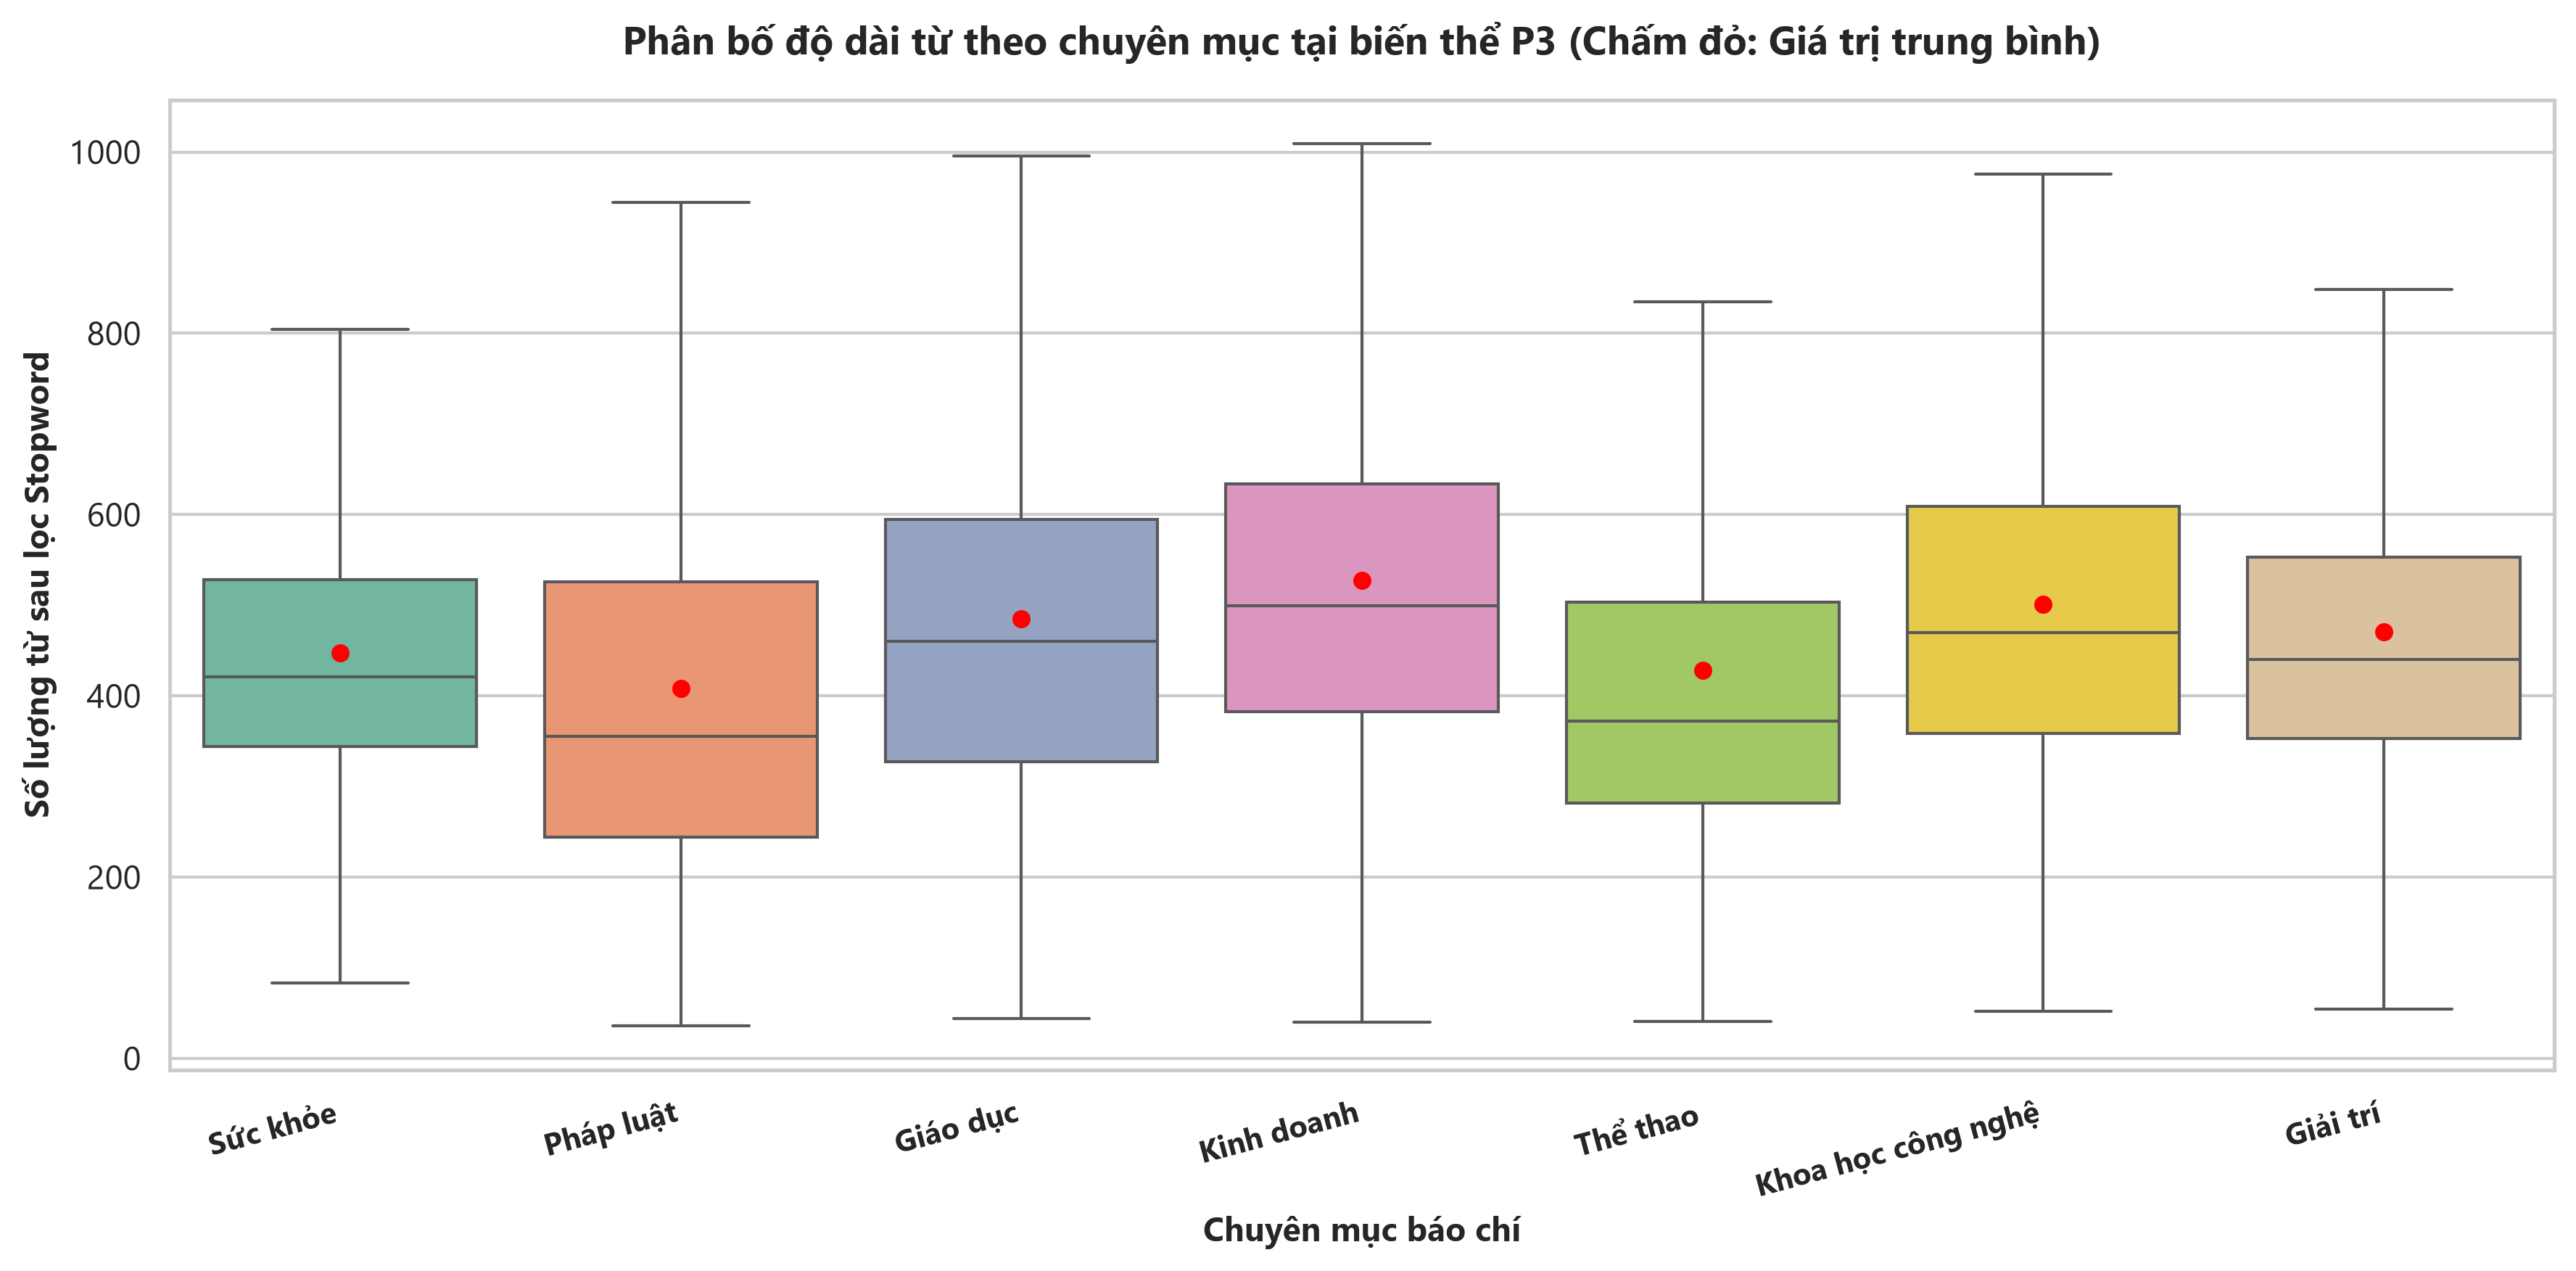

In [37]:
p3_plot_df = p3[["category_gold", "text"]].copy()
p3_plot_df["word_count"] = p3_plot_df["text"].fillna("").apply(lambda s: len(s.split()))

# Vẽ biểu đồ Boxplot độ dài từ theo 7 chuyên mục
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=p3_plot_df,
    x="category_gold",
    y="word_count",
    hue="category_gold",
    legend=False,
    ax=ax,
    palette="Set2",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": "5"},
    showfliers=False,
)

ax.set_title("Phân bố độ dài từ theo chuyên mục tại biến thể P3 (Chấm đỏ: Giá trị trung bình)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Chuyên mục báo chí", fontsize=11, fontweight="bold")
ax.set_ylabel("Số lượng từ sau lọc Stopword", fontsize=11, fontweight="bold")
plt.xticks(rotation=15, ha="right", fontsize=10, fontweight="bold")
plt.tight_layout()

fig.savefig(FIG_DIR / "d03_length_by_category_boxplot.png", bbox_inches="tight")
plt.show()


## 7. Rà soát cảnh báo sụt giảm độ dài >20% do lọc Boilerplate ở P1

Theo ràng buộc kỹ thuật của đặc tả: Cần cảnh báo và ghi nhận danh sách các bài viết bị giảm trên 20% độ dài ở P1.


Tổng số bài viết bị cảnh báo giảm >20% độ dài: 29 / 9,274 bài (Tỷ lệ: 0.31%)


,article_id,source,category_gold,p0_len,p1_len,reduction_pct
0,TTR_0b67da9c1ae3,tuoitre,Giải trí,3744,788,78.95
1,TTR_17333921dc87,tuoitre,Thể thao,4664,3423,26.61
2,TTR_3fca147ad958,tuoitre,Sức khỏe,6310,4634,26.56
3,TTR_4f7a1a81cb13,tuoitre,Kinh doanh,2822,898,68.18
4,TTR_5568a505b698,tuoitre,Giải trí,3411,1872,45.12
5,TTR_c5a16b27dac9,tuoitre,Giáo dục,4875,1783,63.43
6,TTR_d1a8365550a5,tuoitre,Giáo dục,5714,328,94.26
7,TTR_ef0e2be105b0,tuoitre,Giải trí,15110,2283,84.89
8,TTR_f20ad3b450a9,tuoitre,Kinh doanh,3276,2580,21.25
9,VNE_1e24711e9a88,vnexpress,Pháp luật,3204,1382,56.87


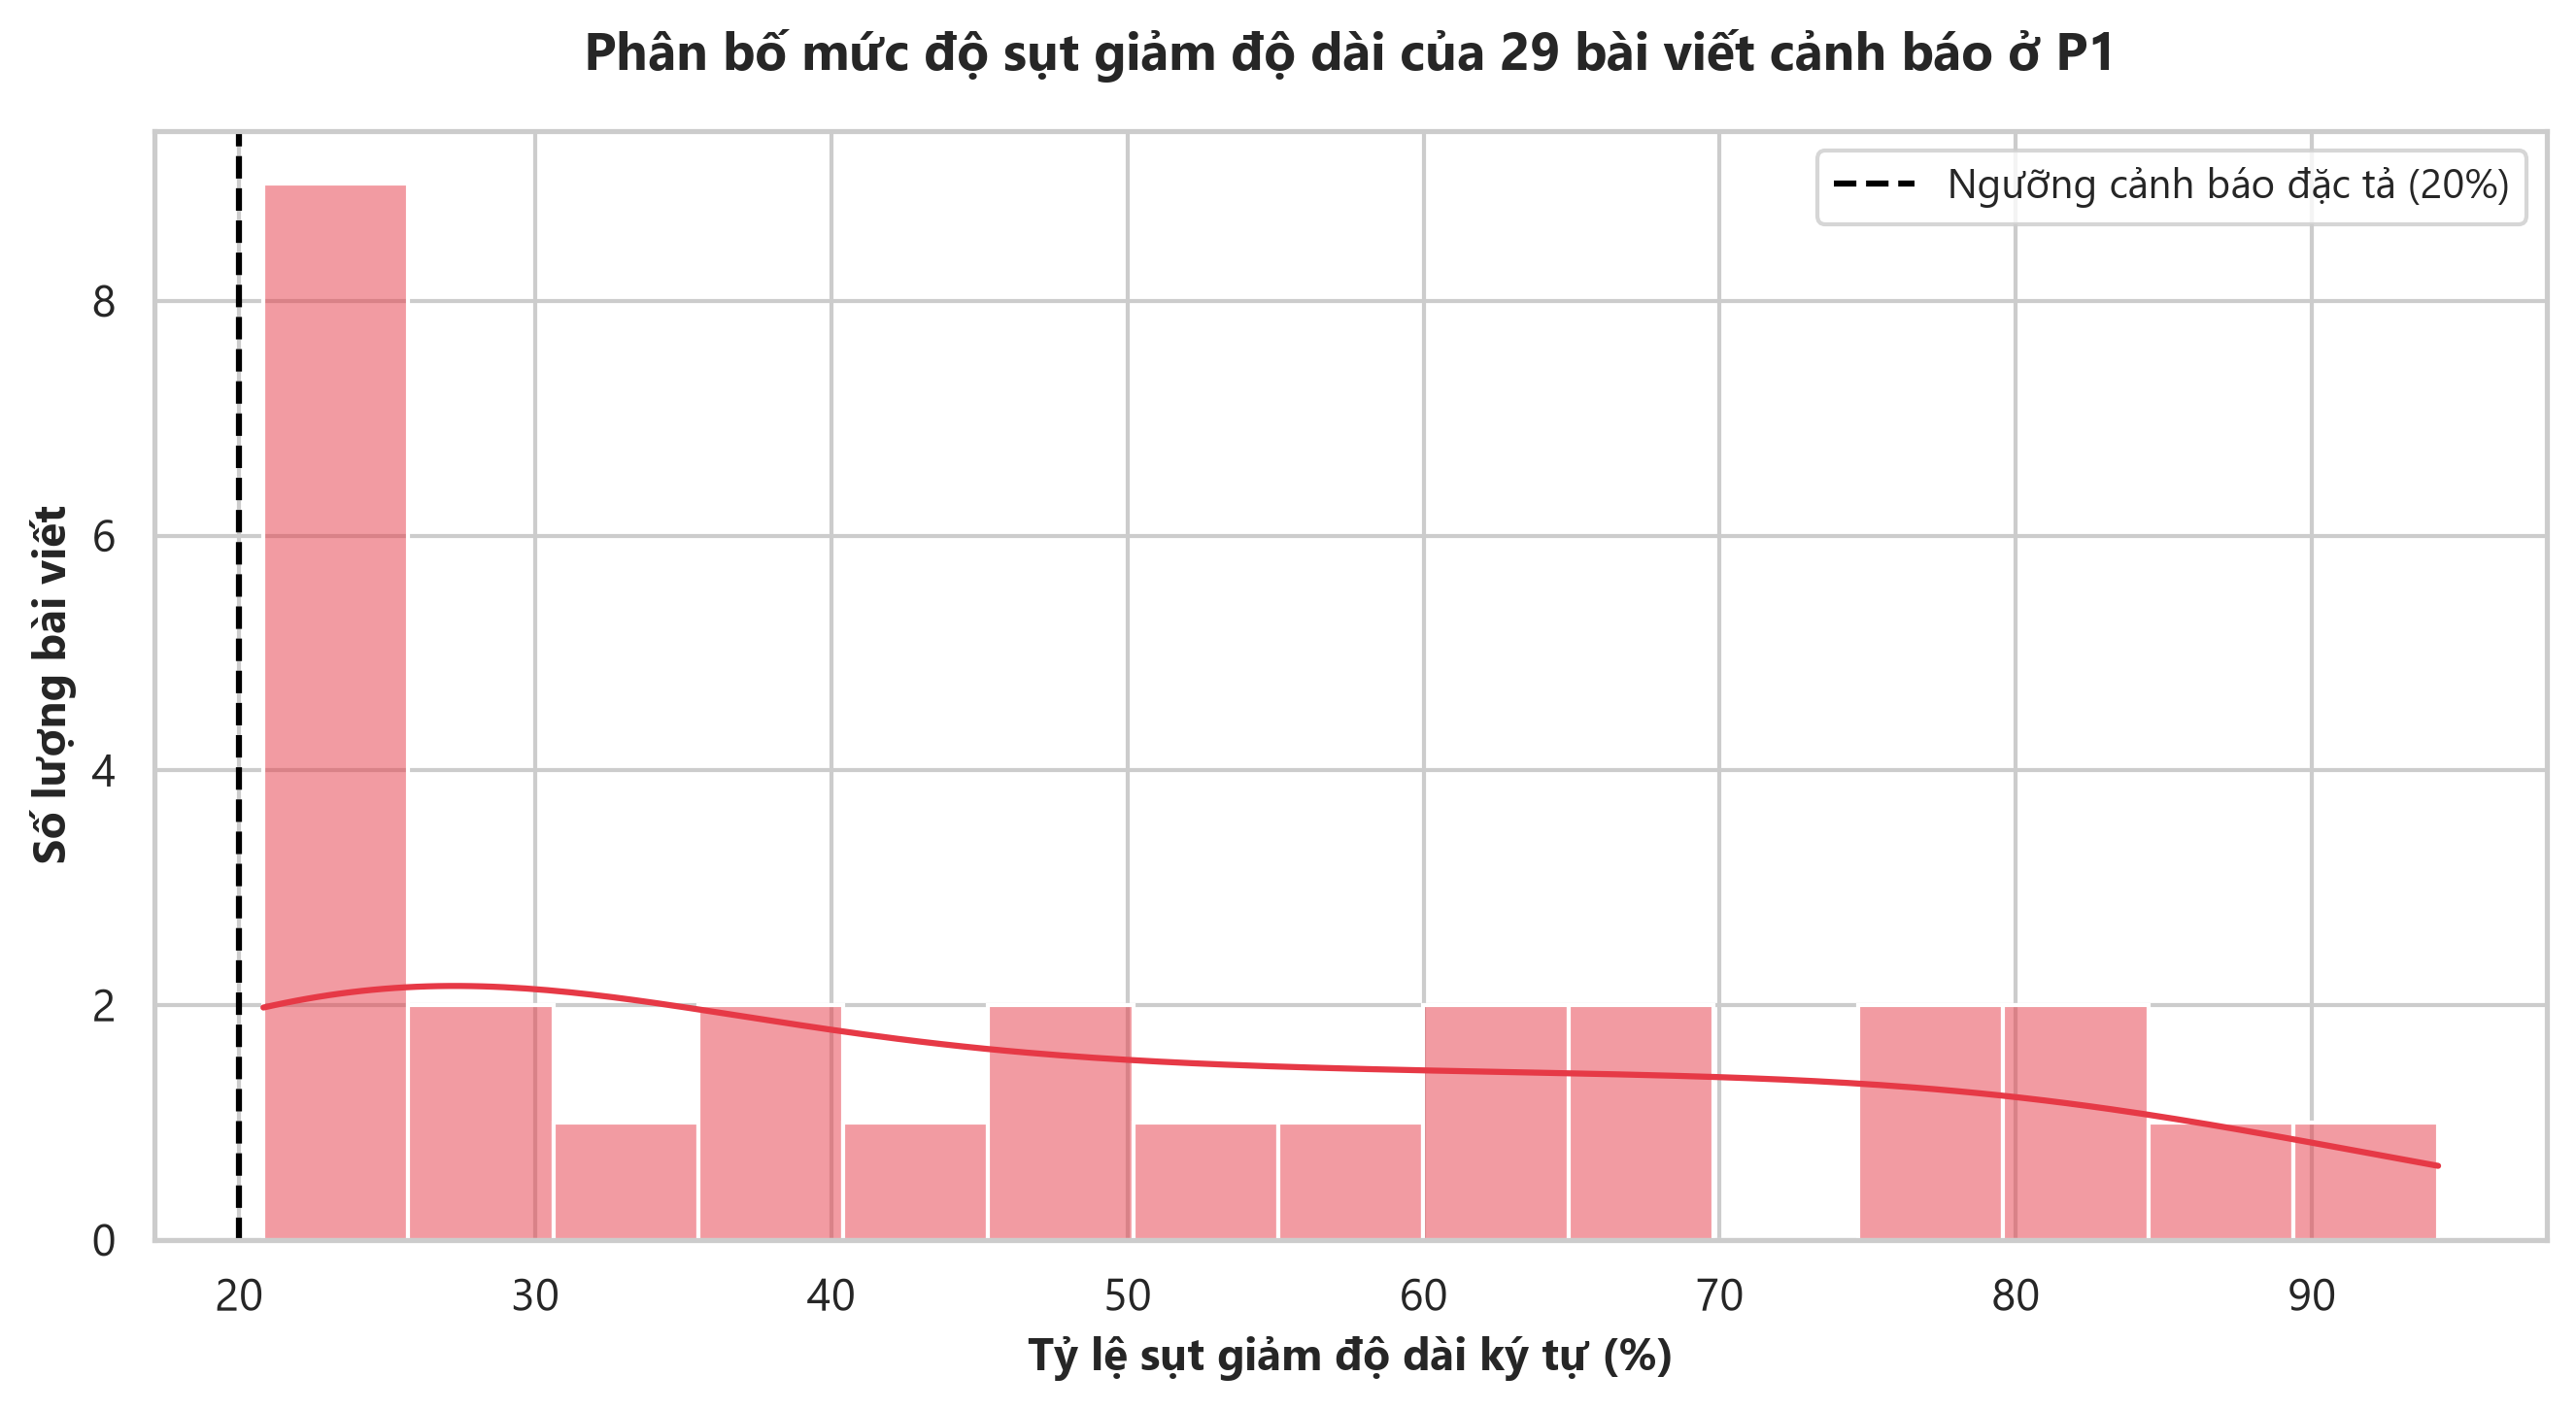

In [38]:
warnings_df = pd.read_csv(RESULTS_DIR / "preprocessing_data/p1_length_drop_warnings.csv")
print(f"Tổng số bài viết bị cảnh báo giảm >20% độ dài: {len(warnings_df)} / 9,274 bài (Tỷ lệ: {len(warnings_df)/9274*100:.2f}%)")
display(warnings_df.head(10))

# Vẽ biểu đồ phân bố mức độ sụt giảm độ dài của các bài cảnh báo
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(warnings_df["reduction_pct"], bins=15, kde=True, ax=ax, color="#e63946")
ax.axvline(20, color="black", linestyle="--", linewidth=1.5, label="Ngưỡng cảnh báo đặc tả (20%)")
ax.set_title("Phân bố mức độ sụt giảm độ dài của 29 bài viết cảnh báo ở P1", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Tỷ lệ sụt giảm độ dài ký tự (%)", fontsize=11, fontweight="bold")
ax.set_ylabel("Số lượng bài viết", fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()

fig.savefig(FIG_DIR / "d03_p1_length_drop_analysis.png", bbox_inches="tight")
plt.show()


## 8. Bảng đối chiếu mẫu 4 biến thể song song 

Đối chiếu trực quan cùng một bài viết qua từng bước chuyển dịch từ bản gốc -> P0 -> P1 -> P2 -> P3:


In [39]:
samples_df = pd.read_csv(RESULTS_DIR / "preprocessing_data/preprocessing_samples.csv")
print(f"Đã nạp {len(samples_df)} mẫu ngẫu nhiên từ preprocessing_samples.csv")

row0 = samples_df.iloc[0]
print(f"=== Article ID: {row0['article_id']} ===")
print(f"[ORIGINAL]: {row0['original_content'][:180]}...")
print(f"[P0]: {row0['p0_text'][:180]}...")
print(f"[P1]: {row0['p1_text'][:180]}...")
print(f"[P2]: {row0['p2_text'][:180]}...")
print(f"[P3]: {row0['p3_text'][:180]}...")


Đã nạp 25 mẫu ngẫu nhiên từ preprocessing_samples.csv
=== Article ID: TTR_0a02d71925aa ===
[ORIGINAL]: Ngày 22-9, An Giang tổ chức ngày hội thu hoạch mô hình nuôi tôm càng xanh luân canh trên đất lúa tại ấp Bình Hòa, xã Vĩnh Bình. Tại đây, lãnh đạo phòng ban chuyên môn trong tỉnh và...
[P0]: Nông dân An Giang thắng lớn khi nuôi tôm càng xanh luân canh trên đất lúa Ngày 22-9, An Giang tổ chức ngày hội thu hoạch mô hình nuôi tôm càng xanh luân canh trên đất lúa tại ấp Bì...
[P1]: nông dân an giang thắng lớn khi nuôi tôm càng xanh luân canh trên đất lúa ngày 22-9, an giang tổ chức ngày hội thu hoạch mô hình nuôi tôm càng xanh luân canh trên đất lúa tại ấp bì...
[P2]: nông_dân an_giang thắng lớn khi nuôi tôm_càng xanh luân_canh trên đất lúa ngày 22 - 9 , an_giang tổ_chức ngày hội thu_hoạch mô_hình nuôi tôm_càng xanh luân_canh trên đất lúa tại ấp...
[P3]: nông_dân an_giang thắng lớn nuôi tôm_càng xanh luân_canh đất lúa 22 - 9 , an_giang tổ_chức hội thu_hoạch mô_hình nuôi tôm_càng xanh luân_